# Project 1 — Step 2: EDA on OUR OWN synthetic hospital dataset

This notebook runs the same kind of exploratory analysis as the Synthea notebook.
but on the dataset we built ourselves (from the pediatric dentistry price list +
generated patient records).]

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

FILE_PATH = "hospital_patient_dataset.xlsx"  # change if your file is elsewhere

df = pd.read_excel(FILE_PATH, sheet_name="Patient_Dataset")
price_list = pd.read_excel(FILE_PATH, sheet_name="Treatment_Price_List")

print(df.shape)
df.head()

(250, 25)


,Patient_ID,Age,Gender,BMI,Blood_Glucose_mgdL,Systolic_BP,Diastolic_BP,Cholesterol_mgdL,Smoking_Status,Family_History_Diabetes,...,Care_Setting,Previous_Admissions,Previous_Visits_1Yr,Medications_Count,Length_of_Stay_Days,Treatment_Cost_INR,Diabetic_Status,Emergency_Visit_Risk,Readmitted_30_Days,Stay_Longer_Than_5_Days
0,PT0001,23,Male,25.4,92,126,75,198,Never,Yes,...,Outpatient,2,1,1,2,3620,Not Diabetic,High,Yes,No
1,PT0002,7,Male,24.3,85,80,52,131,Not applicable (minor),Yes,...,Outpatient,0,0,1,0,837,Not Diabetic,Low,No,No
2,PT0003,10,Male,21.8,79,102,70,133,Not applicable (minor),Yes,...,Outpatient,1,2,6,1,2289,Not Diabetic,Low,Yes,No
3,PT0004,7,Female,16.7,90,119,72,160,Not applicable (minor),No,...,Outpatient,1,2,0,0,250,Not Diabetic,Low,No,No
4,PT0005,25,Female,29.6,98,117,71,199,Never,No,...,Outpatient,0,1,1,0,938,Not Diabetic,Low,Yes,No


## 1. Structure and missing values

In [2]:
print(df.dtypes)
print()
missing = df.isna().sum()
print(missing[missing > 0])

Patient_ID                       object
Age                               int64
Gender                           object
BMI                             float64
Blood_Glucose_mgdL                int64
Systolic_BP                       int64
Diastolic_BP                      int64
Cholesterol_mgdL                  int64
Smoking_Status                   object
Family_History_Diabetes          object
Family_History_Heart_Disease     object
Primary_Diagnosis                object
Comorbidities                    object
Admission_Type                   object
Treatment_Procedure              object
Care_Setting                     object
Previous_Admissions               int64
Previous_Visits_1Yr               int64
Medications_Count                 int64
Length_of_Stay_Days               int64
Treatment_Cost_INR                int64
Diabetic_Status                  object
Emergency_Visit_Risk             object
Readmitted_30_Days               object
Stay_Longer_Than_5_Days          object


## 2. Demographics

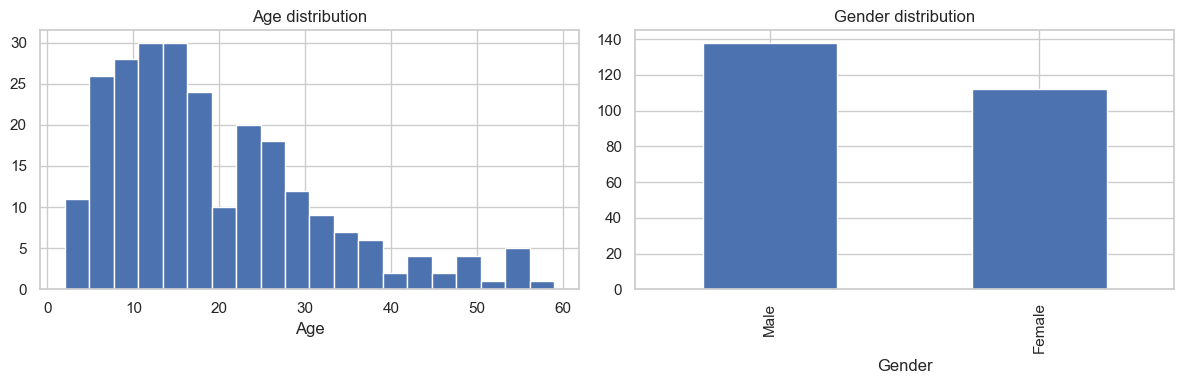

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Age"].hist(bins=20, ax=axes[0])
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age")

df["Gender"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Gender distribution")
plt.tight_layout()
plt.show()

## 3. Diagnoses and procedures

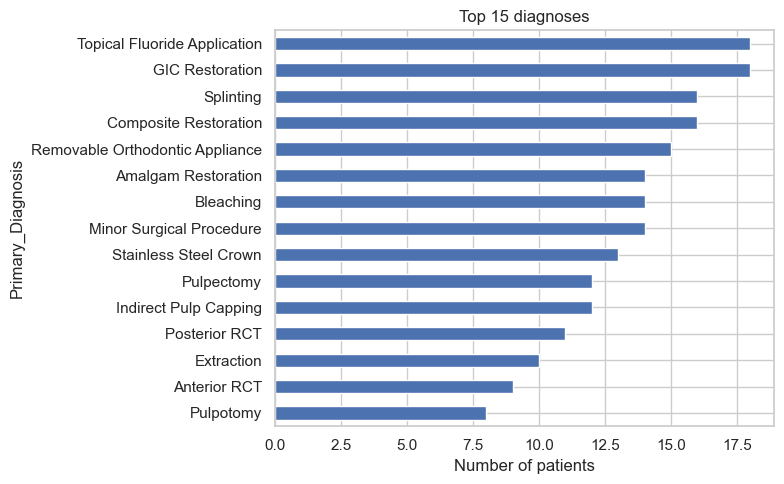

In [4]:
top_diag = df["Primary_Diagnosis"].value_counts().head(15)
top_diag.plot(kind="barh")
plt.title("Top 15 diagnoses")
plt.xlabel("Number of patients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Admission type, length of stay, and cost

Admission_Type
Elective           119
Routine Checkup     69
Emergency           62
Name: count, dtype: int64


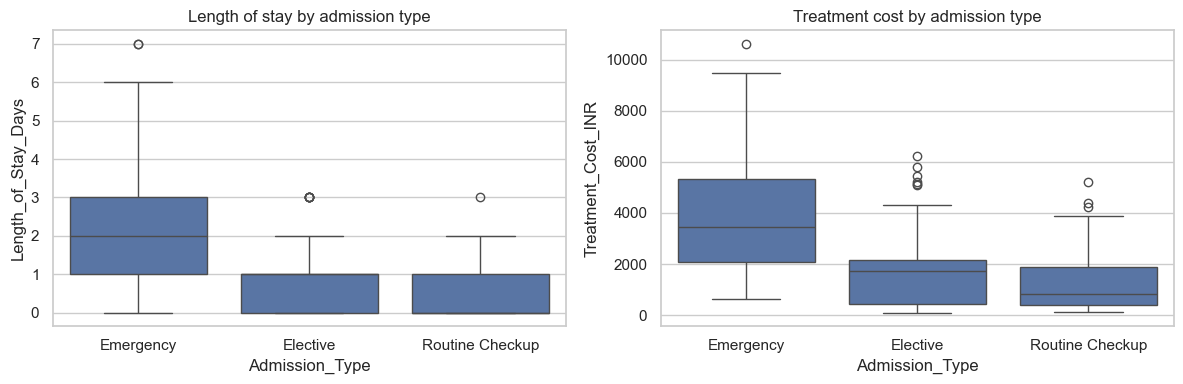

In [5]:
print(df["Admission_Type"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="Admission_Type", y="Length_of_Stay_Days", ax=axes[0])
axes[0].set_title("Length of stay by admission type")

sns.boxplot(data=df, x="Admission_Type", y="Treatment_Cost_INR", ax=axes[1])
axes[1].set_title("Treatment cost by admission type")
plt.tight_layout()
plt.show()

## 5. Comorbidities and vitals

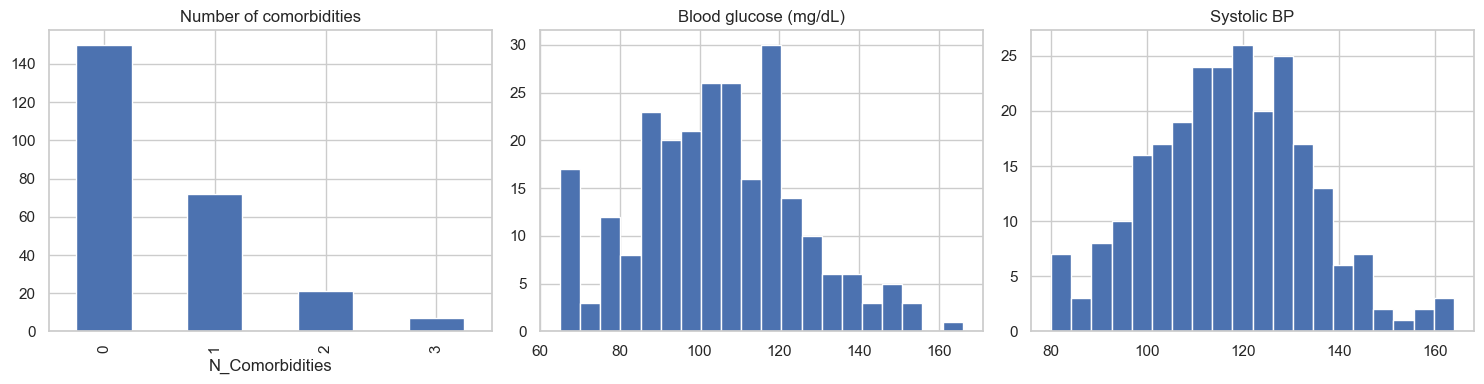

In [6]:
df["N_Comorbidities"] = df["Comorbidities"].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip().lower() == "none" else len(str(x).split(","))
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["N_Comorbidities"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Number of comorbidities")

df["Blood_Glucose_mgdL"].hist(bins=20, ax=axes[1])
axes[1].set_title("Blood glucose (mg/dL)")

df["Systolic_BP"].hist(bins=20, ax=axes[2])
axes[2].set_title("Systolic BP")
plt.tight_layout()
plt.show()

## 6. Target label distributions (what we'll predict in Step 3/4)

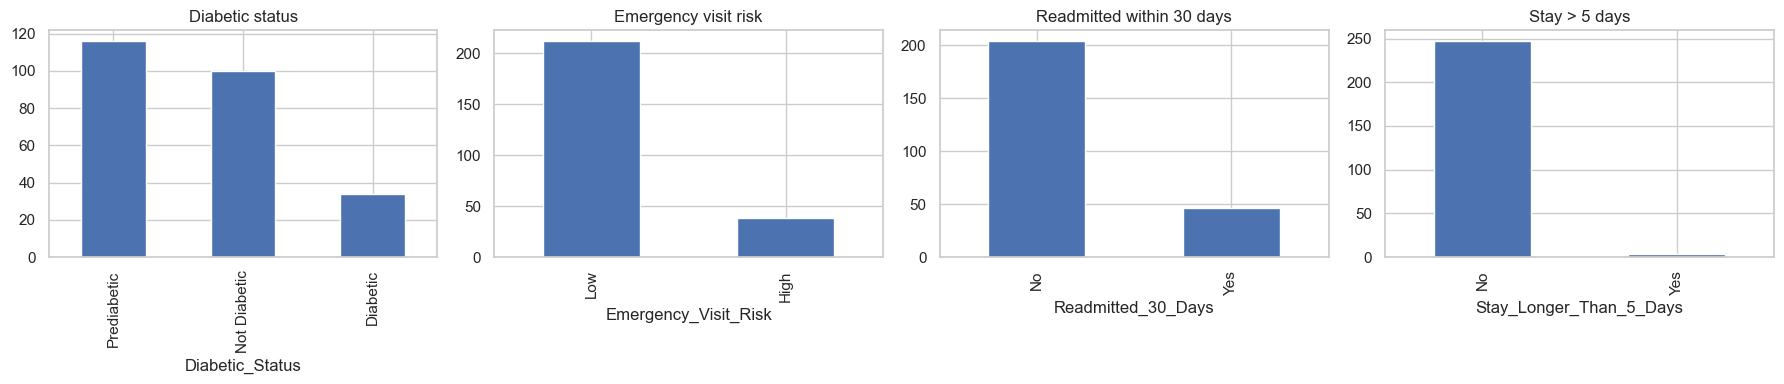

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
df["Diabetic_Status"].value_counts().plot(kind="bar", ax=axes[0], title="Diabetic status")
df["Emergency_Visit_Risk"].value_counts().plot(kind="bar", ax=axes[1], title="Emergency visit risk")
df["Readmitted_30_Days"].value_counts().plot(kind="bar", ax=axes[2], title="Readmitted within 30 days")
df["Stay_Longer_Than_5_Days"].value_counts().plot(kind="bar", ax=axes[3], title="Stay > 5 days")
plt.tight_layout()
plt.show()

## 7. Correlation heatmap (numeric features)

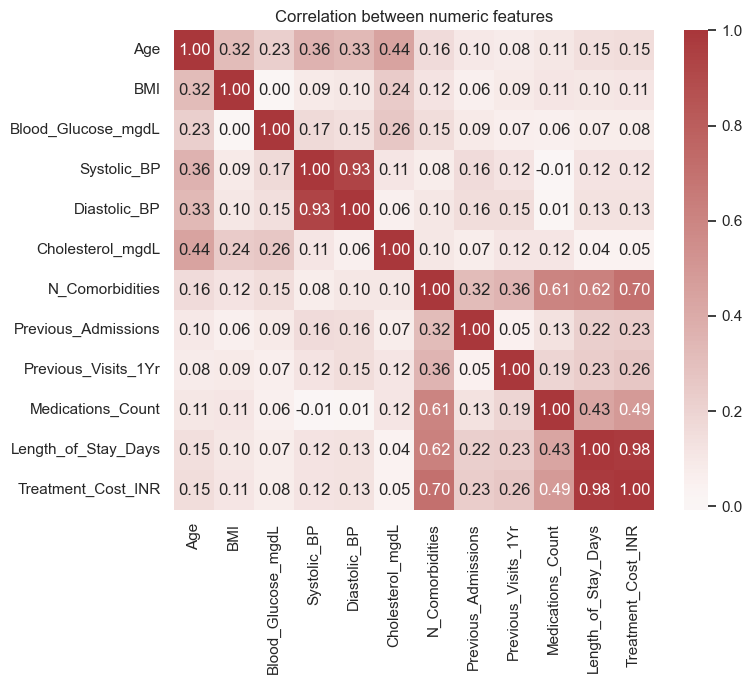

In [8]:
numeric_cols = ["Age", "BMI", "Blood_Glucose_mgdL", "Systolic_BP", "Diastolic_BP", "Cholesterol_mgdL",
                "N_Comorbidities", "Previous_Admissions", "Previous_Visits_1Yr", "Medications_Count",
                "Length_of_Stay_Days", "Treatment_Cost_INR"]

plt.figure(figsize=(8, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()